# Evaluating predicted splice-usage trajectories against the reference clustering

Each **predicted** developmental trajectory is placed into the *fixed* clustering of the
**observed (true)** trajectories — never re-clustered independently — and scored on whether it
lands in the same cluster / shape as its observed counterpart.

Pipeline (all in `alphagenome_pytorch.clustering`, driven by `scripts/cluster_predictions.py`):
1. Load the true-trajectory clustering as a reference and take its per-cluster **centroids**.
2. GP-smooth the predicted **and** observed trajectories with the *identical* transform
   (same kernel, true reads as weights) so they live in the reference feature space.
3. Assign each to the nearest centroid → `pred_shape` / `obs_shape` (+ cluster ids).
4. Compare **pred vs obs** (apples-to-apples, same pipeline) and **pred vs the canonical Ward
   reference** labels.

> **Use shape, not cluster, as the metric.** With ~80 fine clusters, nearest-centroid on
> freshly-fit GPs is brittle (even re-smoothed *observed* trajectories only recover their Ward
> cluster ~40% of the time). Shape (14 labels) is robust — re-smoothed observed reproduces the
> reference shape ~0.79 of the time, which is the ceiling for `same_shape`.

## Setup

In [7]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome_pytorch.clustering import SHAPE_ORDER, SHAPE_COLORS

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [8]:
# ── Config ────────────────────────────────────────────────────────────────────
SPECIES_LIST = ["human", "mouse"]     # species with prediction-cluster results for TISSUE
SPECIES = SPECIES_LIST[0]             # species used for the detailed sections (3-5)
TISSUE  = "Brain"
SPLIT   = "test"

ROOT   = "/home/elek/sds/sd17d003/Anamaria"
MODEL  = "lora_32_human_mouse_rat_rabbit_opossum"
BASE   = os.path.join(ROOT, "alphagenome_genomicsxai", MODEL, "preds_all_intersect_protein_coding")
REF_DIR    = os.path.join(ROOT, "gp_splice_usage")                                   # true-clustering
PREDS_TMPL = os.path.join(BASE, "{species}", "usage_{species}.parquet")              # predicted usage
USAGE_TMPL = os.path.join(ROOT, "alphagenome_genomicsxai", "data",
                          "combined_usage_data_{species}.parquet")                   # true reads/strand

def prefix(sp=None, tis=None, split=None):
    sp, tis, split = sp or SPECIES, tis or TISSUE, split or SPLIT
    return f"{sp}_{tis.replace(' ', '_')}_{split}"

def out_dir(sp=None, tis=None):
    sp, tis = sp or SPECIES, tis or TISSUE
    return os.path.join(BASE, sp, "pred_gp_splice_usage", tis.replace(" ", "_"))

def pred_clusters_path(sp=None, tis=None, split=None):
    return os.path.join(out_dir(sp, tis), f"{prefix(sp, tis, split)}_prediction_clusters.parquet")

OUT_DIR       = out_dir()                 # used by the detailed sections (plots saved here)
PRED_CLUSTERS = pred_clusters_path()
print("detailed species/tissue:", SPECIES, "/", TISSUE)
print("annotated parquet:", PRED_CLUSTERS)
print("exists:", os.path.exists(PRED_CLUSTERS))

detailed species/tissue: human / Brain
annotated parquet: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_all_intersect_protein_coding/human/pred_gp_splice_usage/Brain/human_Brain_test_prediction_clusters.parquet
exists: True


## 1 — Load the annotated prediction clusters

If the parquet is missing, run `scripts/cluster_predictions.py` for this species/tissue (GP
smoothing of both trajectories — a few minutes per tissue).

In [9]:
if not os.path.exists(PRED_CLUSTERS):
    print("Not found - computing via scripts/cluster_predictions.py ...")
    subprocess.run([
        "python", "../../scripts/cluster_predictions.py",
        "--species", SPECIES, "--tissue", TISSUE, "--split", SPLIT,
        "--ref-dir", REF_DIR, "--output", OUT_DIR,
        "--preds-template", PREDS_TMPL, "--usage-template", USAGE_TMPL,
    ], check=True)

df = pd.read_parquet(PRED_CLUSTERS)
print(f"{SPECIES}/{TISSUE}: {len(df):,} sites  |  columns: {list(df.columns)}")
df.head()

human/Brain: 15,544 sites  |  columns: ['Chromosome', 'Position', 'Strand', 'ref_cluster', 'ref_shape', 'obs_cluster', 'obs_shape', 'pred_cluster', 'pred_shape', 'same_cluster', 'same_shape', 'same_cluster_ref', 'same_shape_ref', 'pred_centroid_dist', 'obs_centroid_dist', 'n_obs']


,Chromosome,Position,Strand,ref_cluster,ref_shape,obs_cluster,obs_shape,pred_cluster,pred_shape,same_cluster,same_shape,same_cluster_ref,same_shape_ref,pred_centroid_dist,obs_centroid_dist,n_obs
0,1,1535506,-,76,complex,77,complex,54,up_early,False,False,False,False,0.184013,0.153443,15
1,1,1535588,-,65,flat_high,77,complex,52,up_early,False,False,False,False,0.146763,0.131440,15
2,1,1535796,-,77,complex,52,up_early,54,up_early,False,True,False,False,0.178015,0.128846,15
3,1,1539683,-,52,up_early,54,up_early,49,up_early,False,True,False,True,0.239764,0.228173,15
4,1,1539789,-,49,up_early,49,up_early,54,up_early,False,True,False,True,0.276733,0.349835,15


## 2 — Headline agreement

- **pred vs obs** — both trajectories through the identical GP + nearest-centroid pipeline
  (isolates prediction error from classifier noise). This is the metric to use downstream.
- **pred vs ref** — predicted vs the canonical Ward reference label of the observed site.
- **obs vs ref** — re-smoothed observed vs Ward reference = the pipeline's reproducibility
  ceiling.

In [10]:
def frac(mask): return float(np.mean(mask)) if len(mask) else float("nan")

summary = pd.DataFrame({
    "shape": [frac(df["same_shape"]), frac(df["same_shape_ref"]),
              frac(df["obs_shape"] == df["ref_shape"])],
    "cluster": [frac(df["same_cluster"]), frac(df["same_cluster_ref"]),
                frac(df["obs_cluster"] == df["ref_cluster"])],
}, index=["pred vs obs", "pred vs ref (Ward)", "obs vs ref (ceiling)"]).round(3)
print(f"{SPECIES}/{TISSUE}  —  {len(df):,} sites")
display(summary)

human/Brain  —  15,544 sites


,shape,cluster
pred vs obs,0.253,0.050
pred vs ref (Ward),0.219,0.032
obs vs ref (ceiling),0.789,0.412


## 2b — All species at a glance (this tissue)

Per-species shape/cluster agreement for `TISSUE`, over every species in `SPECIES_LIST` that has a
prediction-cluster parquet.

In [11]:
rows = []
for sp in SPECIES_LIST:
    path = pred_clusters_path(sp, TISSUE, SPLIT)
    if not os.path.exists(path):
        print(f"{sp}: no parquet ({path}) - skipping"); continue
    d = pd.read_parquet(path)
    rows.append(dict(
        species=sp, n_sites=len(d),
        shape_pred_vs_obs=round(d["same_shape"].mean(), 3),
        shape_pred_vs_ref=round(d["same_shape_ref"].mean(), 3),
        shape_obs_vs_ref=round((d["obs_shape"] == d["ref_shape"]).mean(), 3),   # ceiling
        cluster_pred_vs_obs=round(d["same_cluster"].mean(), 3),
    ))
species_summary = pd.DataFrame(rows).set_index("species")
display(species_summary)

,n_sites,shape_pred_vs_obs,shape_pred_vs_ref,shape_obs_vs_ref,cluster_pred_vs_obs
species,,,,,
human,15544,0.253,0.219,0.789,0.050
mouse,11086,0.318,0.308,0.862,0.041


## 3 — Shape concordance: observed vs predicted

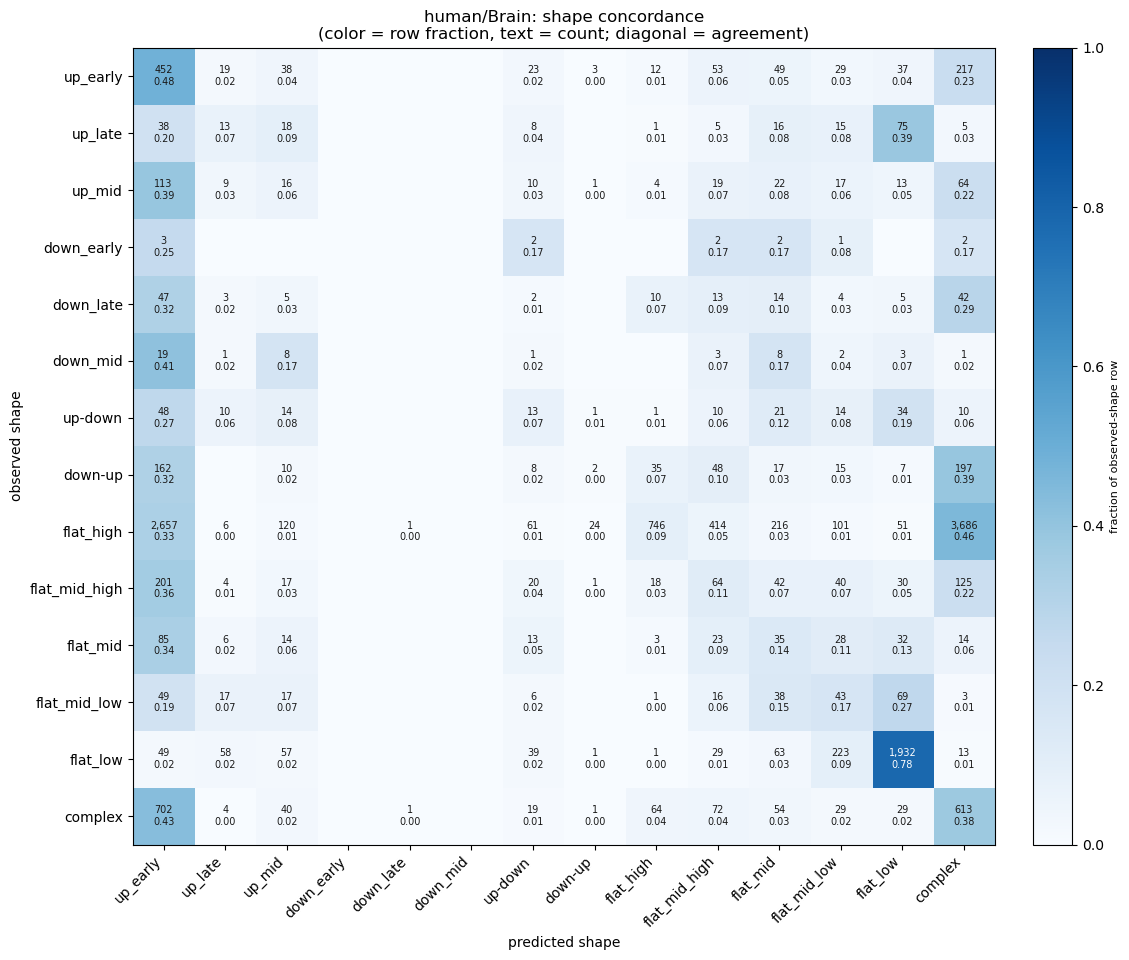

In [12]:
shapes = [s for s in SHAPE_ORDER if s in set(df["obs_shape"]) | set(df["pred_shape"])]
ct = pd.crosstab(df["obs_shape"], df["pred_shape"]).reindex(index=shapes, columns=shapes, fill_value=0)
frac_rows = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(shapes) + 3), max(5, 0.55 * len(shapes) + 2)))
im = ax.imshow(frac_rows.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(shapes))); ax.set_xticklabels(shapes, rotation=45, ha="right")
ax.set_yticks(range(len(shapes))); ax.set_yticklabels(shapes)
ax.set_xlabel("predicted shape"); ax.set_ylabel("observed shape")
ax.set_title(f"{SPECIES}/{TISSUE}: shape concordance\n(color = row fraction, text = count; diagonal = agreement)")
for i in range(len(shapes)):
    for j in range(len(shapes)):
        f = frac_rows.iloc[i, j]
        if ct.iloc[i, j]:
            ax.text(j, i, f"{int(ct.iloc[i, j]):,}\n{f:.2f}" if np.isfinite(f) else f"{int(ct.iloc[i, j]):,}",
                    ha="center", va="center", fontsize=7,
                    color="white" if (np.isfinite(f) and f > 0.5) else "#1a1a1a")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("fraction of observed-shape row", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f"{prefix()}_shape_concordance.png"), dpi=200, bbox_inches="tight")
plt.show()

## 4 — Per-shape agreement and effect of coverage / centroid distance

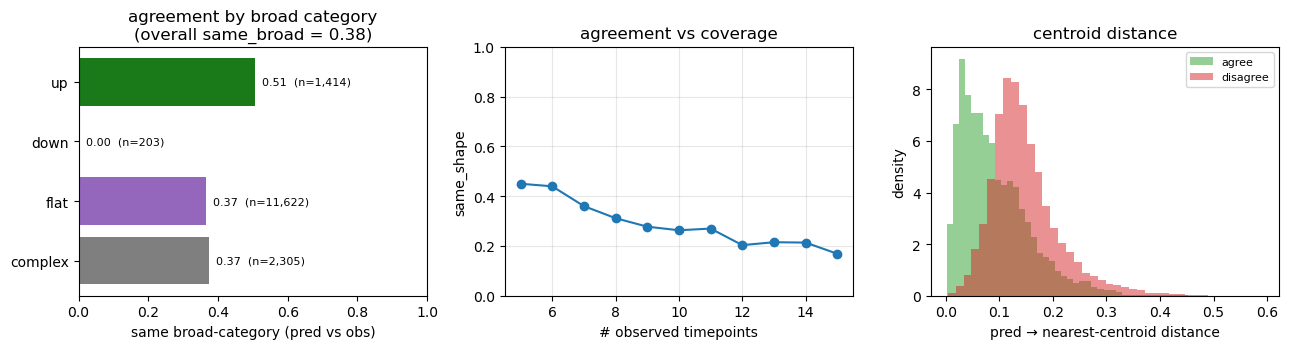

In [32]:
# broad categories: up / down / flat / complex (biphasic up-down/down-up fold into complex)
BROAD = {**{s: "up"   for s in ["up_early", "up_late", "up_mid"]},
         **{s: "down" for s in ["down_early", "down_late", "down_mid"]},
         **{s: "flat" for s in ["flat_low", "flat_mid_low", "flat_mid", "flat_mid_high", "flat_high"]},
         "up-down": "complex", "down-up": "complex", "complex": "complex"}
BROAD_ORDER  = ["up", "down", "flat", "complex"]
BROAD_COLORS = {"up": "#1a7a1a", "down": "#a01010", "flat": "#9467bd", "complex": "#7f7f7f"}
def broad(s): return BROAD.get(s, "complex")

df["obs_broad"]  = df["obs_shape"].map(broad)
df["pred_broad"] = df["pred_shape"].map(broad)
df["same_broad"] = df["obs_broad"] == df["pred_broad"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# (a) per observed broad-category agreement (pred broad == obs broad)
by_broad = (df.groupby("obs_broad")["same_broad"].agg(["mean", "size"])
              .reindex(BROAD_ORDER).dropna())
ax = axes[0]
ax.barh(range(len(by_broad)), by_broad["mean"],
        color=[BROAD_COLORS[b] for b in by_broad.index])
ax.set_yticks(range(len(by_broad))); ax.set_yticklabels(by_broad.index)
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("same broad-category (pred vs obs)")
ax.set_title(f"agreement by broad category\n(overall same_broad = {df['same_broad'].mean():.2f})")
for i, (m, n) in enumerate(zip(by_broad["mean"], by_broad["size"])):
    ax.text(min(m + 0.02, 0.98), i, f"{m:.2f}  (n={int(n):,})", va="center", fontsize=8)

# (b) agreement vs observed timepoints
ax = axes[1]
g = df.groupby("n_obs")["same_shape"].mean()
ax.plot(g.index, g.values, "o-", color="#1f77b4")
ax.set_xlabel("# observed timepoints"); ax.set_ylabel("same_shape"); ax.set_ylim(0, 1)
ax.set_title("agreement vs coverage"); ax.grid(alpha=0.3)

# (c) predicted-centroid distance, agree vs disagree
ax = axes[2]
for lab, sub, c in [("agree", df[df["same_shape"]], "#2ca02c"),
                    ("disagree", df[~df["same_shape"]], "#d62728")]:
    ax.hist(sub["pred_centroid_dist"], bins=40, alpha=0.5, label=lab, color=c, density=True)
ax.set_xlabel("pred → nearest-centroid distance"); ax.set_ylabel("density")
ax.set_title("centroid distance"); ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f"{prefix()}_agreement_breakdown.png"), dpi=200, bbox_inches="tight")
plt.show()

## 5 — Example trajectories: predicted vs observed

A few sites where the predicted shape **matches** the observed one, and a few where it **differs**
— true (solid) vs predicted (dashed) SSE over developmental time.

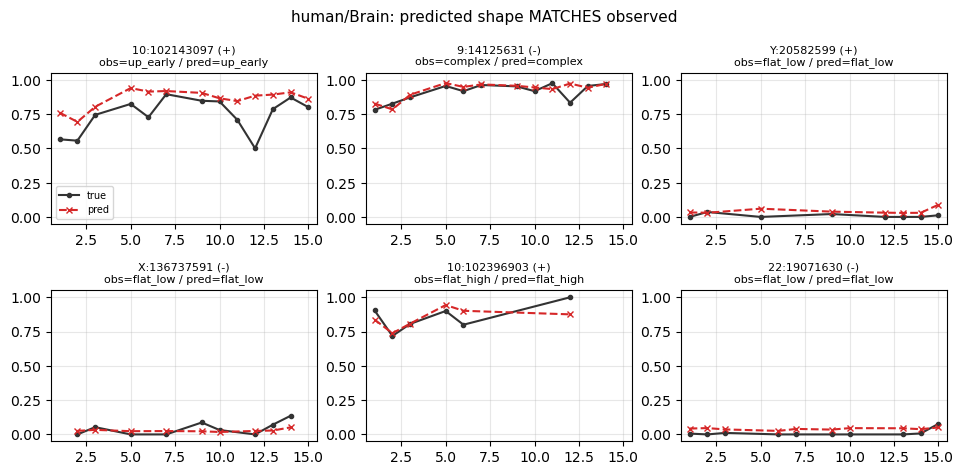

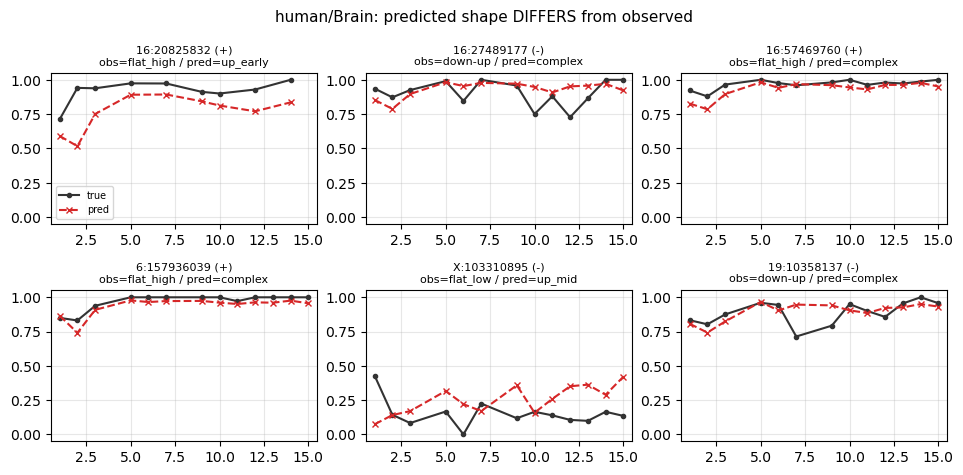

In [22]:
# pull raw SSE_true / SSE_pred over time for chosen sites
_preds = pd.read_parquet(PREDS_TMPL.format(species=SPECIES),
                         columns=["Chromosome", "Position", "Tissue", "Timepoint",
                                  "SSE_true", "SSE_pred"])
_preds = _preds[_preds["Tissue"] == TISSUE].copy()
_preds["Chromosome"] = _preds["Chromosome"].astype(str)

def _traj(chrom, pos):
    s = _preds[(_preds["Chromosome"] == str(chrom)) & (_preds["Position"] == int(pos))]
    s = s.sort_values("Timepoint")
    return s["Timepoint"].to_numpy(), s["SSE_true"].to_numpy(), s["SSE_pred"].to_numpy()

def show_examples(sub, title, n=6):
    sub = sub.head(n)
    ncol = min(3, len(sub)); nrow = (len(sub) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.2, nrow * 2.4), squeeze=False)
    for ax, (_, r) in zip(axes.flat, sub.iterrows()):
        t, yt, yp = _traj(r["Chromosome"], r["Position"])
        ax.plot(t, yt, "-o", ms=3, color="#333", label="true")
        ax.plot(t, yp, "--x", ms=4, color="#d62728", label="pred")
        ax.set_ylim(-0.05, 1.05); ax.set_xlim(0.5, 15.5)
        ax.set_title(f"{r['Chromosome']}:{r['Position']} ({r['Strand']})\n"
                     f"obs={r['obs_shape']} / pred={r['pred_shape']}", fontsize=8)
        ax.grid(alpha=0.3)
    for ax in axes.flat[len(sub):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=7, loc="best")
    fig.suptitle(title, fontsize=11); plt.tight_layout()
    plt.show()

rng = np.random.default_rng(0)
agree = df[df["same_shape"]].sample(frac=1, random_state=0)
disagree = df[~df["same_shape"]].sample(frac=1, random_state=0)
show_examples(agree, f"{SPECIES}/{TISSUE}: predicted shape MATCHES observed")
show_examples(disagree, f"{SPECIES}/{TISSUE}: predicted shape DIFFERS from observed")